In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
def smith_waterman(seq1, seq2, match=2, mismatch=-1, gap=-1):
    rows= len(seq1) + 1 
    cols= len(seq2) + 1 
    
    score_matrix= np.zeros((rows,cols))
    traceback_matrix= np.zeros((rows,cols))
    
    max_score= 0
    max_pos= (0, 0)
    
    for i in range(1, rows):
        for j in range(1, cols):
            diagonal= score_matrix[i-1][j-1] + (match if seq1[i-1] == seq2[j-1] else mismatch)
            up= score_matrix[i-1][j] + gap 
            left= score_matrix[i][j-1] + gap 
            
            score= max(0, diagonal, up, left)
            score_matrix[i][j]= score
            
            if score == diagonal:
                traceback_matrix[i][j] = 1
            elif score== up:
                traceback_matrix[i][j] = 2
            elif score==left:
                traceback_matrix[i][j] = 3
                
            if score > max_score:
                max_score = score
                max_pos = (i, j)

    return score_matrix, traceback_matrix, max_pos

def traceback(seq1, seq2, score_matrix, start_pos):

    aligned1 = ""
    aligned2 = ""

    i, j = start_pos

    while score_matrix[i][j] != 0:

        if seq1[i-1] == seq2[j-1]:
            aligned1 = seq1[i-1] + aligned1
            aligned2 = seq2[j-1] + aligned2
            i -= 1
            j -= 1

        elif score_matrix[i-1][j] > score_matrix[i][j-1]:
            aligned1 = seq1[i-1] + aligned1
            aligned2 = "-" + aligned2
            i -= 1

        else:
            aligned1 = "-" + aligned1
            aligned2 = seq2[j-1] + aligned2
            j -= 1

    return aligned1, aligned2


seq1 = "ACACACTA"
seq2 = "AGCACACA"

score_matrix, traceback_matrix, max_pos = smith_waterman(seq1, seq2)

aligned1, aligned2 = traceback(seq1, seq2, score_matrix, max_pos)

print("Best Local Alignment:")
print(aligned1)
print(aligned2)


Best Local Alignment:
A-CACACTA
AGCACAC-A


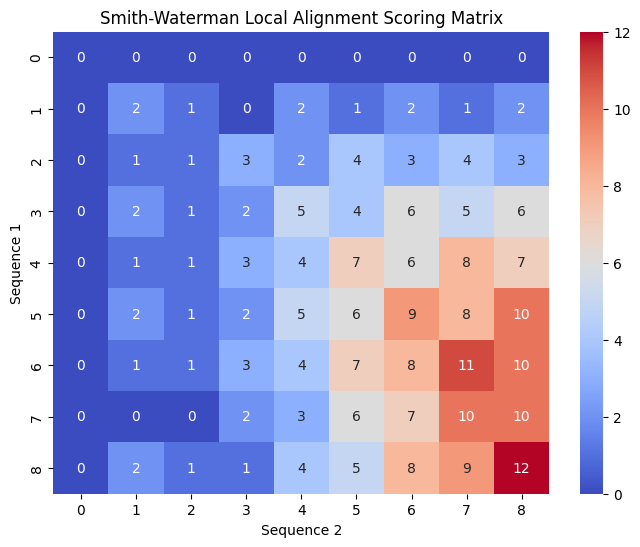

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(score_matrix, 
            annot=True, cmap="coolwarm")
plt.title("Smith-Waterman Local Alignment Scoring Matrix")
plt.xlabel("Sequence 2")
plt.ylabel("Sequence 1")
plt.show()